### Домашнее задание для той же задачи

Возьмите **один** из датасетов:
- `imdb`
- `ag_news`

Что надо поменять:
1. колонки текста и label,
2. число классов,
3. метрику (для `ag_news` лучше macro-F1 + accuracy).

Подсказка:
- `imdb` — бинарная классификация, похоже на SST-2
- `ag_news` — 4 класса

In [1]:
# @title 0. Установка библиотек
!pip -q install -U transformers datasets evaluate accelerate seqeval scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.4 MB/s eta 0:00:00


In [2]:
# @title 1. Импорты и базовые настройки
import os
import random
import numpy as np
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


In [3]:
model_checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# @title 10. Заготовка для домашки: text classification на другом датасете
# Пример: раскомментируйте и адаптируйте под imdb или ag_news


hw_raw = load_dataset("imdb")
print(hw_raw)
print(hw_raw["train"][0])

def preprocess_hw(batch):
     return tokenizer(batch["text"], truncation=True, max_length=256)

hw_tok = hw_raw.map(preprocess_hw, batched=True)

num_labels = 2  # imdb -> 2, ag_news -> 4
hw_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
 )

print(hw_model)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [5]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [6]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_sst2(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

In [7]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = hw_tok["train"].shuffle(seed=42).select(range(1000))
eval_dataset = hw_tok["test"].shuffle(seed=42).select(range(1000))

In [8]:
from collections import Counter
print(Counter(eval_dataset["label"]))

Counter({0: 512, 1: 488})


In [14]:
# Хотим примерно 10 валидаций за эпоху
steps_per_epoch = len(train_dataset) // 64
#eval_steps = max(1, steps_per_epoch // 10)
eval_steps = 5
print("Approx. steps per epoch:", steps_per_epoch)
print("Validation every", eval_steps, "steps")

training_args = TrainingArguments(
    output_dir="./bert-imdb",
    eval_strategy="epoch",
    eval_steps=eval_steps,
    save_strategy="epoch",
    save_steps=eval_steps,
    logging_strategy="steps",
    logging_steps=20,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_sst2,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Approx. steps per epoch: 15
Validation every 5 steps
{'loss': '0.05822', 'grad_norm': '1.213', 'learning_rate': '3e-05', 'epoch': '0.3175'}
{'loss': '0.291', 'grad_norm': '12.03', 'learning_rate': '2.647e-05', 'epoch': '0.6349'}
{'loss': '0.2178', 'grad_norm': '9.234', 'learning_rate': '2.294e-05', 'epoch': '0.9524'}
{'eval_loss': '0.7116', 'eval_accuracy': '0.791', 'eval_f1': '0.7378', 'eval_runtime': '16.6', 'eval_samples_per_second': '60.23', 'eval_steps_per_second': '1.927', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2816', 'grad_norm': '1.474', 'learning_rate': '1.941e-05', 'epoch': '1.27'}
{'loss': '0.1439', 'grad_norm': '0.3384', 'learning_rate': '1.588e-05', 'epoch': '1.587'}
{'loss': '0.1688', 'grad_norm': '25.62', 'learning_rate': '1.235e-05', 'epoch': '1.905'}
{'eval_loss': '0.5233', 'eval_accuracy': '0.848', 'eval_f1': '0.8521', 'eval_runtime': '15.84', 'eval_samples_per_second': '63.13', 'eval_steps_per_second': '2.02', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.08357', 'grad_norm': '8.172', 'learning_rate': '8.824e-06', 'epoch': '2.222'}
{'loss': '0.05285', 'grad_norm': '0.1825', 'learning_rate': '5.294e-06', 'epoch': '2.54'}
{'loss': '0.03424', 'grad_norm': '15.64', 'learning_rate': '1.765e-06', 'epoch': '2.857'}
{'eval_loss': '0.557', 'eval_accuracy': '0.853', 'eval_f1': '0.8574', 'eval_runtime': '15.78', 'eval_samples_per_second': '63.38', 'eval_steps_per_second': '2.028', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '323.1', 'train_samples_per_second': '9.286', 'train_steps_per_second': '0.585', 'train_loss': '0.1428', 'epoch': '3'}


TrainOutput(global_step=189, training_loss=0.1427553923672469, metrics={'train_runtime': 323.0612, 'train_samples_per_second': 9.286, 'train_steps_per_second': 0.585, 'train_loss': 0.1427553923672469, 'epoch': 3.0})

В ходе выполнения эксперимента были внесены изменения в процесс обучения модели.

Для ускорения обучения и стабилизации результатов были уменьшены размеры обучающей и тестовой выборок:
`train_dataset = hw_tok["train"].shuffle(seed=42).select(range(1000))`
`eval_dataset = hw_tok["test"].shuffle(seed=42).select(range(1000))`.

Также было изменено количество шагов на эпоху: с 62 до 15, что связано с уменьшением размера обучающей выборки и параметра batch size.

Дополнительно была изменена стратегия валидации и сохранения модели: вместо проверки каждые несколько шагов использована проверка по эпохам (`evaluation_strategy="epoch"`, `save_strategy="epoch"`), что позволило снизить  вычислительные ресурсы и сделать процесс обучения более стабильным.

Кроме того, было увеличено значение скорости обучения до `learning_rate = 3e-5`, что способствовало более эффективному обновлению весов модели на начальных этапах обучения.


In [16]:
metrics = trainer.evaluate()
metrics

{'eval_loss': '0.557', 'eval_accuracy': '0.853', 'eval_f1': '0.8574', 'eval_runtime': '17.71', 'eval_samples_per_second': '56.47', 'eval_steps_per_second': '1.807', 'epoch': '3'}


{'eval_loss': 0.5570167899131775,
 'eval_accuracy': 0.853,
 'eval_f1': 0.8574199806013579,
 'eval_runtime': 17.7075,
 'eval_samples_per_second': 56.473,
 'eval_steps_per_second': 1.807,
 'epoch': 3.0}

=== Train logs ===


,step,epoch,loss,grad_norm,learning_rate
0,20,0.317460,0.058220,1.212614,0.000030
1,40,0.634921,0.290979,12.029777,0.000026
2,60,0.952381,0.217796,9.233838,0.000023
4,80,1.269841,0.281584,1.473628,0.000019
5,100,1.587302,0.143948,0.338373,0.000016
6,120,1.904762,0.168845,25.624823,0.000012
8,140,2.222222,0.083573,8.171846,0.000009
9,160,2.539683,0.052850,0.182455,0.000005
10,180,2.857143,0.034238,15.640134,0.000002



=== Eval logs ===


,step,epoch,eval_loss,eval_accuracy,eval_f1,eval_runtime
3,63,1.0,0.711616,0.791,0.737767,16.6022
7,126,2.0,0.523337,0.848,0.852140,15.8409
11,189,3.0,0.557017,0.853,0.857420,15.7780
13,189,3.0,0.557017,0.853,0.857420,17.7075



=== Summary logs ===


,train_runtime,train_samples_per_second,train_steps_per_second,train_loss,epoch
12,323.0612,9.286,0.585,0.142755,3.0


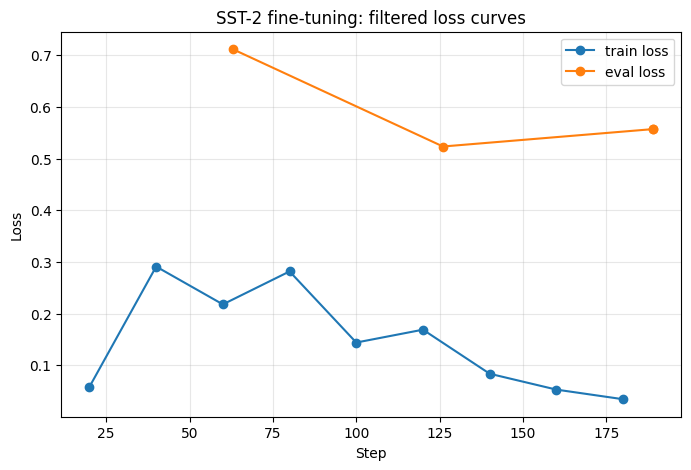

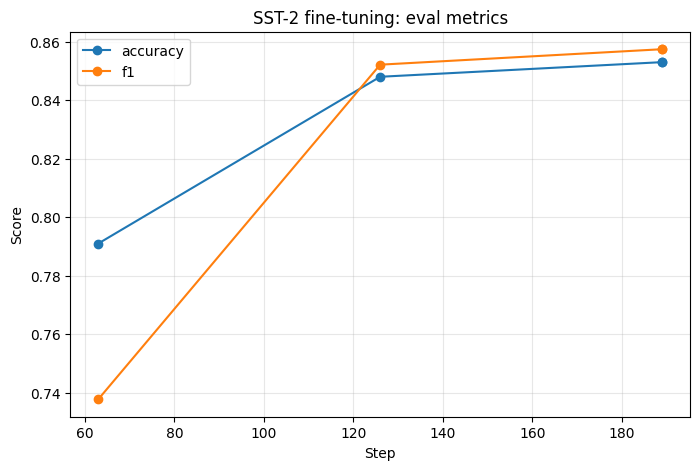

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)

# Отдельно train / eval / итоговые summary-строки
train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train logs ===")
if len(train_logs) > 0:
    cols = [c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"] if c in train_logs.columns]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval logs ===")
if len(eval_logs) > 0:
    cols = [c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1", "eval_runtime"] if c in eval_logs.columns]
    display(eval_logs[cols].tail(10))
else:
    print("Нет eval-логов")

print("\n=== Summary logs ===")
if len(summary_logs) > 0:
    cols = [c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"] if c in summary_logs.columns]
    display(summary_logs[cols].tail(10))
else:
    print("Нет summary-логов")

# 1. Loss curves
plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SST-2 fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Eval metrics
metric_cols = [c for c in ["eval_accuracy", "eval_f1"] if c in eval_logs.columns]

if len(eval_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))
    for col in metric_cols:
        plt.plot(eval_logs["step"], eval_logs[col], marker="o", label=col.replace("eval_", ""))
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("SST-2 fine-tuning: eval metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет eval-метрик для графика")

По графику функции потерь видно, что значение train loss стабильно уменьшается, что свидетельствует об успешном обучении модели. Значение eval loss также сначала уменьшается, однако на последних шагах наблюдается его незначительный рост, что может указывать на начало переобучения.

афик метрик показывает устойчивый рост accuracy и F1-меры, что говорит об улучшении качества модели в процессе обучения. Значения метрик достигают уровня около 0.85, что свидетельствует о хорошем качестве классификации.

В целом можно сделать вывод, что модель обучается корректно и демонстрирует хорошую обобщающую способность, несмотря на незначительные признаки переобучения на завершающем этапе обучения.